In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

def add_source(fig, text):
    """Write the data source under the chart."""
    fig.text(0.01, 0.005, text, fontsize=8, color="#666666", ha="left", va="bottom")

In [2]:
path = "https://raw.githubusercontent.com/AndrewEberhardt/DataScienceProject/main/data/raw/crops/palm-oil-production.csv"
palmoil= pd.read_csv(path)
palmoil.head() 

,Entity,Code,Year,Palm oil - Production (tonnes)
0,Africa,OWID_AFR,1961,1131882.0
1,Africa,OWID_AFR,1962,1111006.0
2,Africa,OWID_AFR,1963,1145004.0
3,Africa,OWID_AFR,1964,1160831.0
4,Africa,OWID_AFR,1965,1138860.0


In [3]:
palmoil_world = palmoil[palmoil["Entity"] == "World"].reset_index(drop=True)
palmoil_world.head()

,Entity,Code,Year,Palm oil - Production (tonnes)
0,World,OWID_WRL,1961,1478901.0
1,World,OWID_WRL,1962,1475941.0
2,World,OWID_WRL,1963,1535070.0
3,World,OWID_WRL,1964,1570032.0
4,World,OWID_WRL,1965,1576213.0


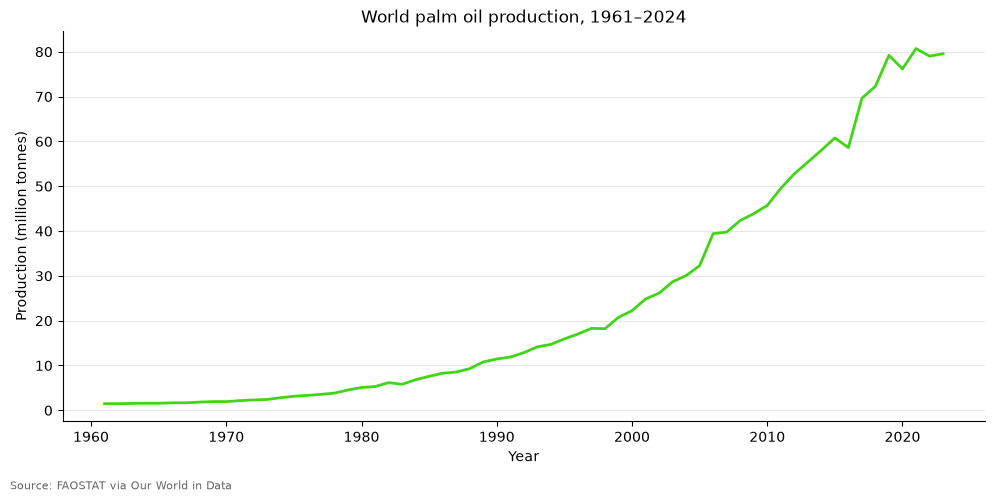

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(palmoil_world["Year"], palmoil_world["Palm oil - Production (tonnes)"] / 1e6, color="#40d616", linewidth=2)
ax.set_title("World palm oil production, 1961–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Production (million tonnes)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()


In [5]:
palmoil_pays = palmoil[palmoil["Code"].notna() & ~palmoil["Code"].str.startswith("OWID_")]

prod_par_pays = (
    palmoil_pays.groupby("Entity")["Palm oil - Production (tonnes)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Entity": "pays", "Palm oil - Production (tonnes)": "production_totale_t"})
)
prod_par_pays.head(20)

,pays,production_totale_t
0,Indonesia,6.950198e+08
1,Malaysia,5.390422e+08
2,Nigeria,5.364498e+07
3,Thailand,4.730950e+07
4,Colombia,3.075215e+07
5,Papua New Guinea,1.578070e+07
6,Cote d'Ivoire,1.511112e+07
7,Ecuador,1.309913e+07
8,Democratic Republic of Congo,1.281043e+07
9,Honduras,1.124607e+07


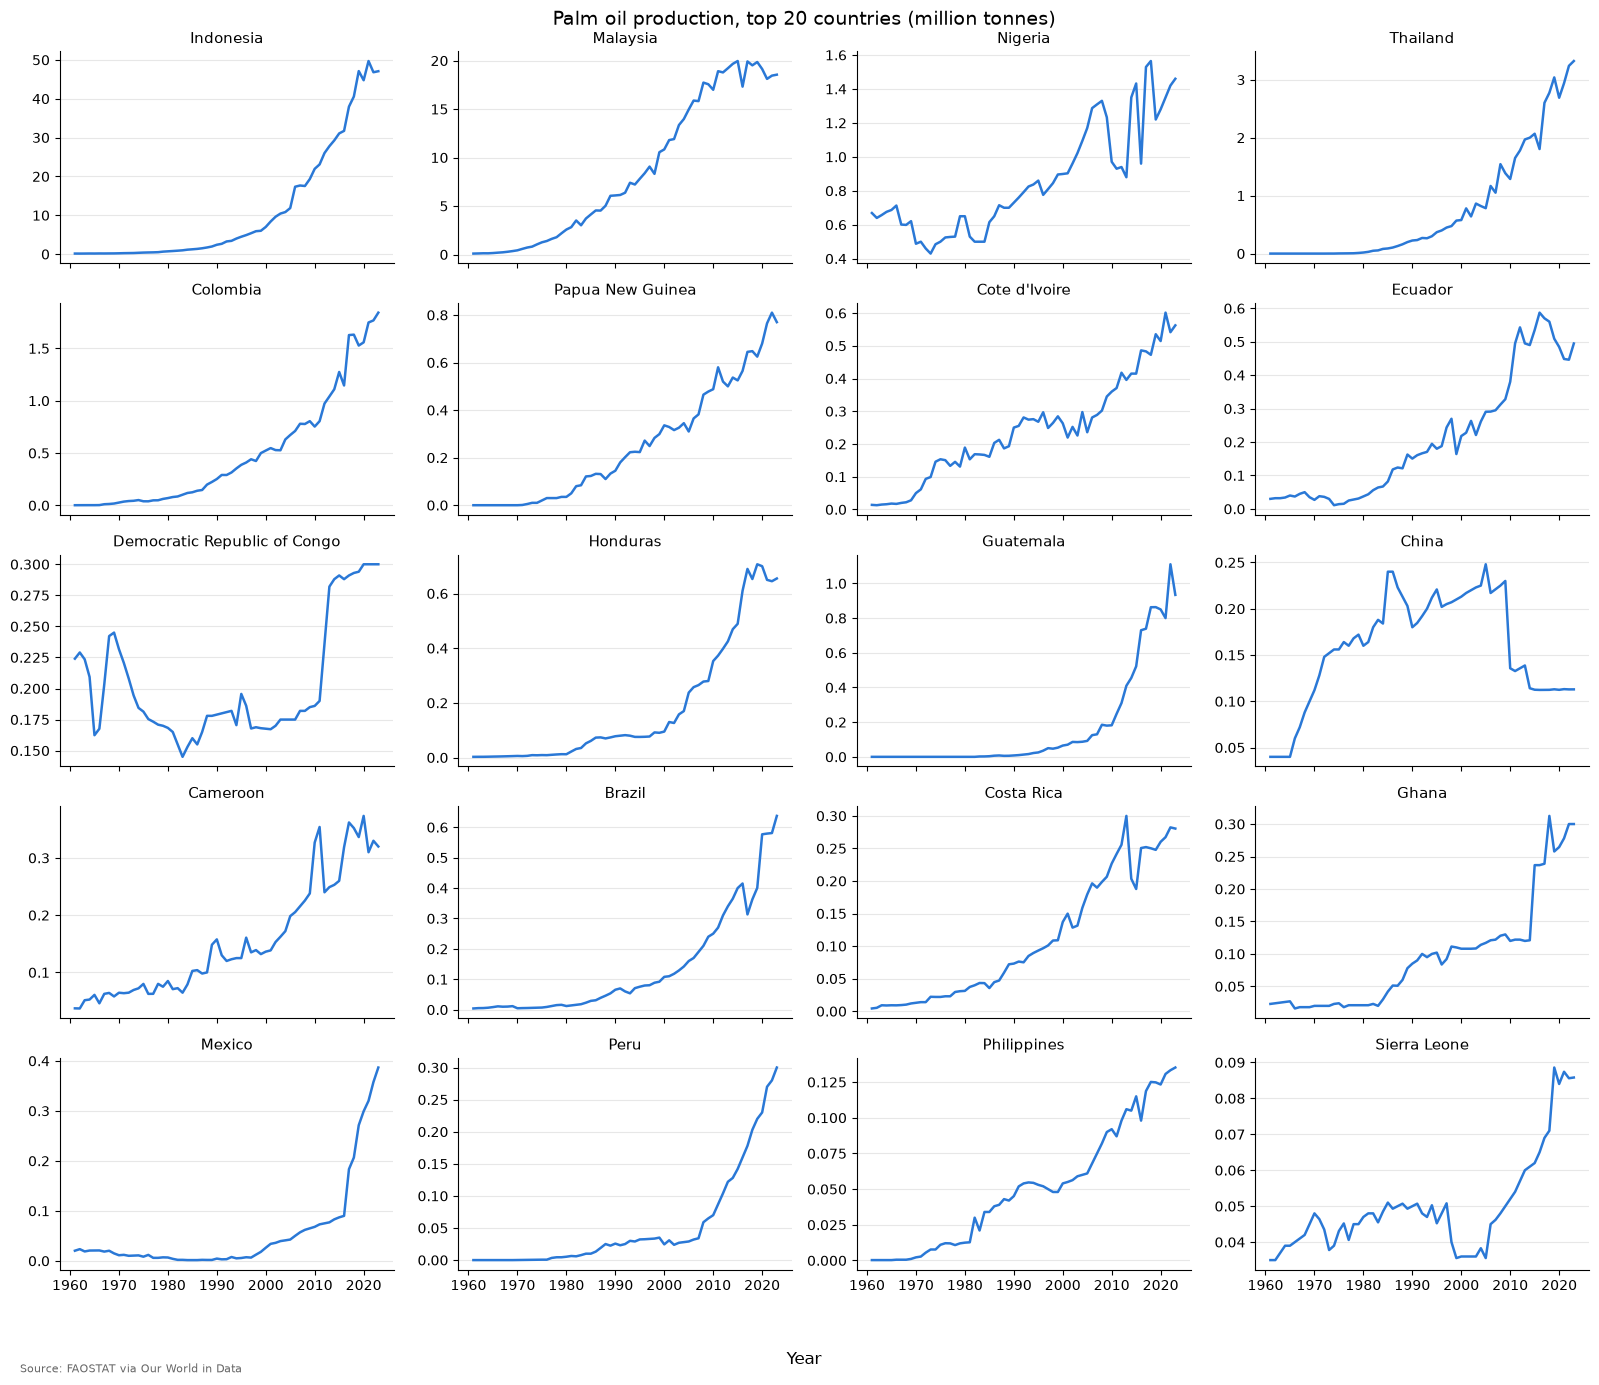

In [6]:
top20 = prod_par_pays.head(20)["pays"].tolist()
data = palmoil_pays[palmoil_pays["Entity"].isin(top20)]

fig, axes = plt.subplots(5, 4, figsize=(16, 14), sharex=True)
for ax, pays in zip(axes.flat, top20):
    d = data[data["Entity"] == pays]
    ax.plot(d["Year"], d["Palm oil - Production (tonnes)"] / 1e6, color="#2a78d6", linewidth=1.8)
    ax.set_title(pays, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Palm oil production, top 20 countries (million tonnes)", fontsize=14)
fig.supxlabel("Year")
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()


In [7]:
prod_par_pays["part_%"] = prod_par_pays["production_totale_t"] / prod_par_pays["production_totale_t"].sum() * 100
prod_par_pays.head

<bound method NDFrame.head of                             pays  production_totale_t     part_%
0                      Indonesia         6.950198e+08  45.704092
1                       Malaysia         5.390422e+08  35.447097
2                        Nigeria         5.364498e+07   3.527662
3                       Thailand         4.730950e+07   3.111045
4                       Colombia         3.075215e+07   2.022243
5               Papua New Guinea         1.578070e+07   1.037729
6                  Cote d'Ivoire         1.511112e+07   0.993698
7                        Ecuador         1.309913e+07   0.861391
8   Democratic Republic of Congo         1.281043e+07   0.842406
9                       Honduras         1.124607e+07   0.739535
10                     Guatemala         1.043623e+07   0.686281
11                         China         9.953929e+06   0.654564
12                      Cameroon         9.666878e+06   0.635688
13                        Brazil         8.554512e+06   0.56

In [8]:
palmoil_pays = palmoil[palmoil["Code"].notna()
                       & ~palmoil["Code"].str.startswith("OWID_")
                       & (palmoil["Year"] >= 1996)]

prod_par_pays = (
    palmoil_pays.groupby("Entity")["Palm oil - Production (tonnes)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Entity": "pays", "Palm oil - Production (tonnes)": "production_totale_t"})
)
prod_par_pays["part_%"] = prod_par_pays["production_totale_t"] / prod_par_pays["production_totale_t"].sum() * 100
prod_par_pays.head(20)


,pays,production_totale_t,part_%
0,Indonesia,6.571869e+08,49.738294
1,Malaysia,4.445908e+08,33.648247
2,Thailand,4.468435e+07,3.381874
3,Nigeria,3.182198e+07,2.408403
4,Colombia,2.708169e+07,2.049640
5,Papua New Guinea,1.341269e+07,1.015121
6,Ecuador,1.061074e+07,0.803059
7,Cote d'Ivoire,1.037731e+07,0.785392
8,Guatemala,1.030726e+07,0.780091
9,Honduras,1.015095e+07,0.768261


In [9]:
gros_producteurs_palm = prod_par_pays.loc[prod_par_pays["part_%"] > 1, "pays"].tolist()
gros_producteurs_palm


['Indonesia',
 'Malaysia',
 'Thailand',
 'Nigeria',
 'Colombia',
 'Papua New Guinea']

In [10]:
pays_palm = ['Cameroon', 'Colombia', "Côte d'Ivoire", 'Ghana', 'Indonesia', 'Malaysia', 'Nigeria']

communs = sorted(set(pays_palm) & set(gros_producteurs_palm))
communs


['Colombia', 'Indonesia', 'Malaysia', 'Nigeria']

These country lists describe who produces the crop. They do not choose the sample of the analysis: the regressions use every country of the deforestation panel, weighted by its own exposure.

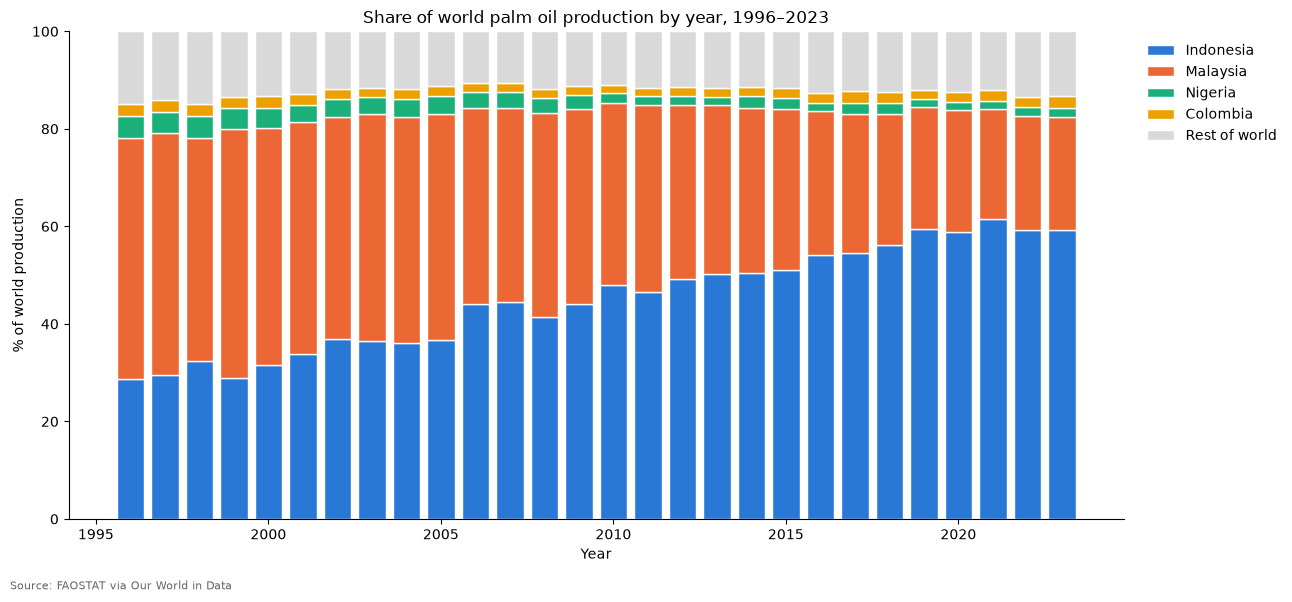

In [11]:
palmoil2 = pd.read_csv(path)
col = "Palm oil - Production (tonnes)"
pays_retenus = ["Indonesia", "Malaysia", "Nigeria", "Colombia"]

# Production par pays et par année, depuis 1996
palm_96 = palmoil2[palmoil2["Year"] >= 1996]
monde = palm_96[palm_96["Entity"] == "World"].set_index("Year")[col]

parts = (palm_96[palm_96["Entity"].isin(pays_retenus)]
         .pivot(index="Year", columns="Entity", values=col)[pays_retenus]
         .div(monde, axis=0) * 100)
parts["Rest of world"] = 100 - parts.sum(axis=1)

couleurs = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#d9d9d9"]

fig, ax = plt.subplots(figsize=(13, 6))
bas = np.zeros(len(parts))
for p, c in zip(parts.columns, couleurs):
    ax.bar(parts.index, parts[p], bottom=bas, color=c, width=0.8,
           edgecolor="white", linewidth=1, label=p)
    bas += parts[p].values

ax.set_title("Share of world palm oil production by year, 1996–2023")
ax.set_xlabel("Year")
ax.set_ylabel("% of world production")
ax.set_ylim(0, 100)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()


thailand manque


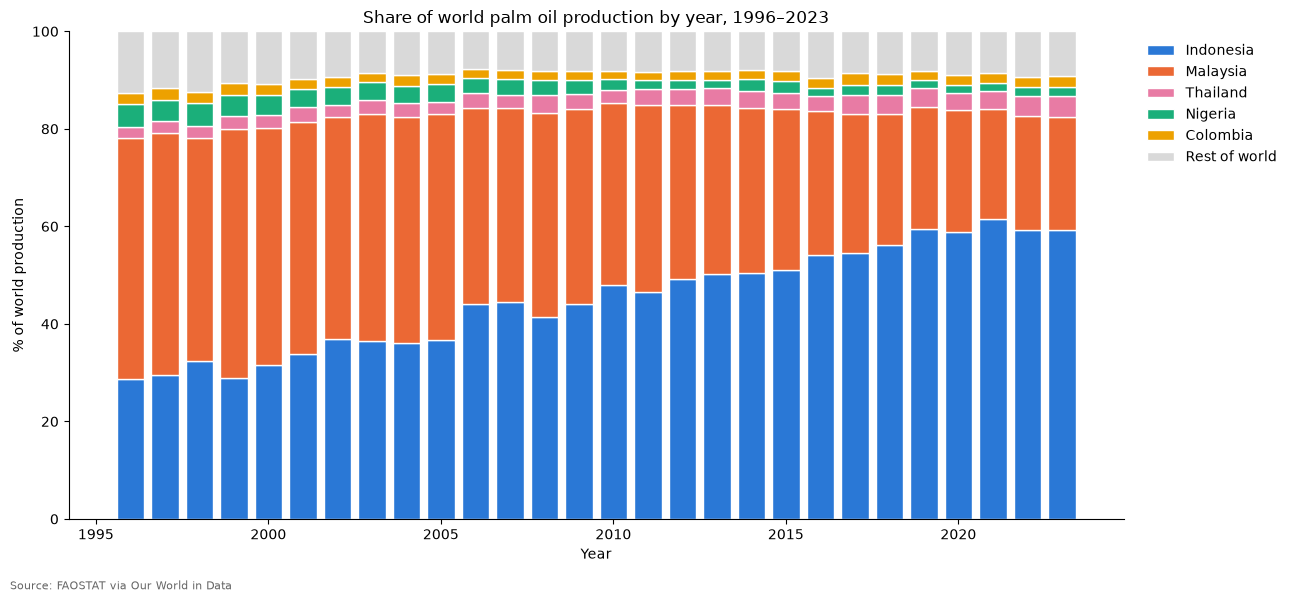

In [12]:
col = "Palm oil - Production (tonnes)"
pays_retenus = ["Indonesia", "Malaysia", "Thailand", "Nigeria", "Colombia"]

# Production par pays et par année, depuis 1996
palm_96 = palmoil[palmoil["Year"] >= 1996]
monde = palm_96[palm_96["Entity"] == "World"].set_index("Year")[col]

parts = (palm_96[palm_96["Entity"].isin(pays_retenus)]
         .pivot(index="Year", columns="Entity", values=col)[pays_retenus]
         .div(monde, axis=0) * 100)
parts["Rest of world"] = 100 - parts.sum(axis=1)

couleurs = ["#2a78d6", "#eb6834", "#e87ba4", "#1baf7a", "#eda100", "#d9d9d9"]

fig, ax = plt.subplots(figsize=(13, 6))
bas = np.zeros(len(parts))
for p, c in zip(parts.columns, couleurs):
    ax.bar(parts.index, parts[p], bottom=bas, color=c, width=0.8,
           edgecolor="white", linewidth=1, label=p)
    bas += parts[p].values

ax.set_title("Share of world palm oil production by year, 1996–2023")
ax.set_xlabel("Year")
ax.set_ylabel("% of world production")
ax.set_ylim(0, 100)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()
